In [106]:
from coffea.util import load
from collections import defaultdict
import numpy as np

# Load the data from the coffea file
output = load("output.coffea")

# Extract the cutflow information
data = output["cutflow"]["total"]

# Cut names mapping for LaTeX
cut_mapping = {
    'n_lep=2': r'$N_l=2$',
    'leadingLepPT': r'$l_{p_T}^{\text{leading}}>25$',
    'OCLep': r'$\text{OC lepton}$',
    'lepInvariantMass': r'$M_{ll}>20$',
    'onePhoton': r'$N_\gamma=1$',
    'atLeastOneBJet': r'$N_{\text{bjet}}>=1$',
    'eft_val': r'$M_{TT} < \Lambda_{\text{eff}}$'
}

# List of cuts in order
cuts = ['n_lep=2', 'leadingLepPT', 'OCLep', 'lepInvariantMass', 'onePhoton', 'atLeastOneBJet', 'eft_val']

# M_TT max values for different samples
mtt_max_values = {
    'ttgamma': {
        3000: 10331.35,
        2750: 10034.372,
        2500: 9686.921,
        2250: 9887.83,
        2000: 8491.792,
        1750: 8629.777,
        1500: 7374.608,
        1250: 7420.108,
        1000: 6036.2544,
        750: 5426.388,
        500: 4044.5098
    },
    'ttgammagamma_dilepton': {
        500: 3815.9294,
        750: 4918.0293,
        1000: 5557.4033,
        1250: 5870.095,
        1500: 7333.3457,
        1750: 6884.1455,
        2000: 8153.2104,
        2250: 8219.112,
        2500: 9034.342,
        2750: 9244.388,
        3000: 9853.23
    },
    'ttgammagamma_semilepton': {
        3000: 10712.06,
        2750: 11248.61,
        2500: 10140.87,
        2250: 10223.8,
        2000: 9238.86,
        1750: 9787.98,
        1500: 10138.76,
        1250: 9514.61,
        1000: 6632.72,
        750: 5841.97,
        500: 5025.38
    }
}

def get_mass_from_sample(sample_name):
    """Extract mass value from sample name"""
    return int(sample_name.split('_')[-1])

def get_sample_group(sample_name):
    """Get sample group (ttaa or Signal)"""
    if sample_name.startswith('ttaa'):
        return 'ttaa'
    elif sample_name.startswith('Signal'):
        return 'Signal'
    return 'unknown'

def get_sample_label(group):
    """Return the LaTeX label for a sample group"""
    if group == 'ttaa':
        return r'tt$\gamma\gamma$'
    elif group == 'Signal':
        return r'tt$\gamma$'
    return group

def get_lambda_eff_threshold(mass, sample_group, output_dir="output.coffea"):
    """
    Get the M_TT max for a given mass and sample group
    For ttaa samples: use ttaa_{mass}
    For Signal samples: use Signal_{mass}
    """
    output = load(output_dir)
    if sample_group == 'ttaa':
        MTT = np.max(output["MTT_array"][f"ttaa_{mass}"].value)
    elif sample_group == 'Signal':
        MTT = np.max(output["MTT_array"][f"Signal_{mass}"].value)
    else:
        MTT = 0
    return MTT

def generate_table1(data, sample_group, scale_factor=0.70):
    """
    Table 1: Selection efficiency (%) for each cut compared to primary
    Using yield values for proper normalization
    Transposed: Masses as rows, cuts as columns
    """
    # Get samples for this group
    samples = {name: info for name, info in data.items() if get_sample_group(name) == sample_group}
    
    # Sort by mass
    sorted_samples = sorted(samples.items(), key=lambda x: get_mass_from_sample(x[0]))
    
    # Get the label for this sample group
    sample_label = get_sample_label(sample_group)
    
    # Build table header with cuts as columns - using |c| for lines between columns
    header = "\\begin{table}[h]\n\\centering\n"
    header += f"\\scalebox{{{scale_factor}}}{{\n"
    header += "\\begin{tabular}{|c|" + "|".join(["c"] * len(cuts)) + "|}\n\\hline\n"
    header += "Mass (GeV) & " + " & ".join([cut_mapping[cut] for cut in cuts]) + " \\\\ \\hline\n"
    
    # Build rows for each mass
    rows = []
    for sample_name, info in sorted_samples:
        mass = get_mass_from_sample(sample_name)
        row = f"{mass}"
        primary_yield = info['yield']['primary']
        for cut in cuts:
            cut_yield = info['yield'][cut]
            efficiency = (cut_yield / primary_yield) * 100 if primary_yield > 0 else 0
            row += f" & {efficiency:.2f}\\%"
        row += " \\\\ \\hline\n"
        rows.append(row)
    
    footer = "\\end{tabular}\n}\n\\caption{Selection efficiency for " + sample_label + " samples}\n\\end{table}"
    
    return header + "".join(rows) + footer

def generate_table2(data, sample_group, scale_factor=0.70):
    """
    Table 2: Efficiency of eft_val cut relative to previous cut for each mass
    Now includes Lambda_eff threshold and two M_TT cut columns
    """
    # Get samples for this group
    samples = {name: info for name, info in data.items() if get_sample_group(name) == sample_group}
    
    # Sort by mass
    sorted_samples = sorted(samples.items(), key=lambda x: get_mass_from_sample(x[0]))
    
    # Get the label for this sample group
    sample_label = get_sample_label(sample_group)
    
    # Build table header - now with 4 columns
    header = "\\begin{table}[h]\n\\centering\n"
    header += f"\\scalebox{{{scale_factor}}}{{\n"
    header += "\\begin{tabular}{|c|c|c|c|}\n\\hline\n"
    header += "Mass (GeV) & $\\Lambda_{\\text{eff}}$ (GeV) & $M_{TT} < \\Lambda_{\\text{eff}} = M_{TT}^{\\text{Max}}$ & $M_{TT} < \\Lambda_{\\text{eff}} 7.07$ (TeV) \\\\ \\hline\n"
    
    # Build rows for each mass
    rows = []
    for sample_name, info in sorted_samples:
        mass = get_mass_from_sample(sample_name)
        
        # Get Lambda_eff threshold (M_TT max) for this mass and sample group
        lambda_eff = get_lambda_eff_threshold(mass, sample_group)
        
        # Get the yield before eft_val cut (atLeastOneBJet)
        previous_cut_yield = info['yield']['atLeastOneBJet']
        eft_val_yield = info['yield']['eft_val']
        
        # Efficiency for the actual eft_val cut (7.07 TeV)
        efficiency_707 = (eft_val_yield / previous_cut_yield) * 100 if previous_cut_yield > 0 else 0
        
        # For M_TT < Lambda_eff = M_TT_Max, efficiency is always 100%
        efficiency_max = 100.0
        
        rows.append(f"{mass} & {lambda_eff:.2f} & {efficiency_max:.2f}\\% & {efficiency_707:.2f}\\% \\\\ \\hline\n")
    
    footer = "\\end{tabular}\n}\n\\caption{Efficiency of $M_{TT} < \\Lambda_{\\text{eff}}$ cuts after all previous cuts for " + sample_label + " samples}\n\\end{table}"
    
    return header + "".join(rows) + footer

def generate_table3(data, scale_factor=0.70):
    """
    Table 3: Two columns showing:
    1. Ratio of ttaa to (ttaa + Signal) after all selections for each mass
    2. Ratio of ttaa to Signal (ttgamma/ttgamma) for same mass
    Using yield values for proper normalization
    Masses as rows, two columns
    """
    # Group samples by mass
    mass_groups = defaultdict(dict)
    
    for sample_name, info in data.items():
        mass = get_mass_from_sample(sample_name)
        group = get_sample_group(sample_name)
        if group in ['ttaa', 'Signal']:
            mass_groups[mass][group] = info['yield']['eft_val']
    
    # Sort by mass
    sorted_masses = sorted(mass_groups.keys())
    
    # Build table header - using |c|c|c| for lines between columns
    header = "\\begin{table}[h]\n\\centering\n"
    header += f"\\scalebox{{{scale_factor}}}{{\n"
    header += "\\begin{tabular}{|c|c|c|}\n\\hline\n"
    header += "Mass (GeV) & $\\frac{\\text{tt}\\gamma\\gamma}{\\text{tt}\\gamma\\gamma + \\text{tt}\\gamma}$ (\\%) & $\\frac{\\text{tt}\\gamma\\gamma}{\\text{tt}\\gamma}$ (\\%) \\\\ \\hline\n"
    
    # Build rows
    rows = []
    for mass in sorted_masses:
        if 'ttaa' in mass_groups[mass] and 'Signal' in mass_groups[mass]:
            ttaa = mass_groups[mass]['ttaa']
            signal = mass_groups[mass]['Signal']  # This is ttgamma
            
            # Calculate ratio 1: ttaa / (ttaa + signal)
            ratio1 = (ttaa / (ttaa + signal)) * 100 if (ttaa + signal) > 0 else 0
            
            # Calculate ratio 2: ttaa / signal (now as percentage)
            ratio2 = (ttaa / signal) * 100 if signal > 0 else 0
            
            rows.append(f"{mass} & {ratio1:.2f}\\% & {ratio2:.2f}\\% \\\\ \\hline\n")
    
    footer = "\\end{tabular}\n}\n\\caption{Ratios of tt$\\gamma\\gamma$ events to tt$\\gamma$ events after all selections}\n\\end{table}"
    
    return header + "".join(rows) + footer

def generate_table4(scale_factor=0.70):
    """
    Table 4: M_TT max values for different samples
    Four columns: Mass, ttgamma, ttgammagamma Dilepton(CMS), ttgammagamma Semilepton(ATLAS)
    """
    # Get all unique masses from the data
    all_masses = sorted(set(mtt_max_values['ttgamma'].keys()) | 
                       set(mtt_max_values['ttgammagamma_dilepton'].keys()) | 
                       set(mtt_max_values['ttgammagamma_semilepton'].keys()))
    
    # Build table header
    header = "\\begin{table}[h]\n\\centering\n"
    header += f"\\scalebox{{{scale_factor}}}{{\n"
    header += "\\begin{tabular}{|c|c|c|c|}\n\\hline\n"
    header += "Mass (GeV) & tt$\\gamma$ & tt$\\gamma\\gamma$ Dilepton (CMS) & tt$\\gamma\\gamma$ Semilepton (ATLAS) \\\\ \\hline\n"
    
    # Build rows
    rows = []
    for mass in all_masses:
        row = f"{mass}"
        
        # Get values for each sample type, use '-' if not available
        ttgamma_val = mtt_max_values['ttgamma'].get(mass, '-')
        ttgammagamma_dilepton_val = mtt_max_values['ttgammagamma_dilepton'].get(mass, '-')
        ttgammagamma_semilepton_val = mtt_max_values['ttgammagamma_semilepton'].get(mass, '-')
        
        # Format values
        if ttgamma_val != '-':
            ttgamma_val = f"{ttgamma_val:.2f}"
        if ttgammagamma_dilepton_val != '-':
            ttgammagamma_dilepton_val = f"{ttgammagamma_dilepton_val:.2f}"
        if ttgammagamma_semilepton_val != '-':
            ttgammagamma_semilepton_val = f"{ttgammagamma_semilepton_val:.2f}"
        
        row += f" & {ttgamma_val} & {ttgammagamma_dilepton_val} & {ttgammagamma_semilepton_val} \\\\ \\hline\n"
        rows.append(row)
    
    footer = "\\end{tabular}\n}\n\\caption{Maximum $M_{TT}$ values for different samples and masses}\n\\end{table}"
    
    return header + "".join(rows) + footer

def generate_complete_tex_file(data, filename="complete_tables.tex"):
    """
    Generate a complete LaTeX file with all tables in frames
    """
    tex_content = """\\documentclass{beamer}
\\usetheme{default}
\\usepackage{amsmath}
\\usepackage{bm}
\\usepackage{booktabs}
\\usepackage{float}
\\usepackage[caption = false]{subfig}
\\usepackage[]{graphicx}
\\usepackage{adjustbox}

\\title{\\textbf{Analysis Tables}}
\\subtitle{Single Lepton Channel}

\\begin{document}
\\begin{frame}[plain]
    \\maketitle
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{tt$\\gamma\\gamma$ Samples Selection Efficiency}
"""
    
    # Add Table 1a
    tex_content += generate_table1(data, 'ttaa', scale_factor=0.70)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{tt$\\gamma$ Samples Selection Efficiency}
"""
    
    # Add Table 1b (Signal samples, now labeled as ttgamma)
    tex_content += generate_table1(data, 'Signal', scale_factor=0.7)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{$M_{TT} < \\Lambda_{\\text{eff}}$ Efficiency (tt$\\gamma\\gamma$)}
"""
    
    # Add Table 2a
    tex_content += generate_table2(data, 'ttaa', scale_factor=0.75)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{$M_{TT} < \\Lambda_{\\text{eff}}$ Efficiency (tt$\\gamma$)}
"""
    
    # Add Table 2b
    tex_content += generate_table2(data, 'Signal', scale_factor=0.75)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{tt$\\gamma\\gamma$ / tt$\\gamma$ Ratios}
"""
    
    # Add Table 3
    tex_content += generate_table3(data, scale_factor=0.75)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{Maximum $M_{TT}$ Values}
"""
    
    # Add Table 4
    tex_content += generate_table4(scale_factor=0.70)
    
    tex_content += """
\\end{frame}

\\end{document}
"""
    
    return tex_content

# Generate and save the complete LaTeX file
tex_content = generate_complete_tex_file(data)
with open("complete_tables.tex", "w") as f:
    f.write(tex_content)

print("Complete LaTeX file has been written to complete_tables.tex")

# Also print individual tables for reference
print("\n" + "=" * 80)
print("TABLE 1a: tt$\\gamma\\gamma$ samples - Selection efficiency")
print("=" * 80)
print(generate_table1(data, 'ttaa', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 1b: tt$\\gamma$ samples - Selection efficiency")
print("=" * 80)
print(generate_table1(data, 'Signal', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 2a: tt$\\gamma\\gamma$ samples - eft_val efficiency")
print("=" * 80)
print(generate_table2(data, 'ttaa', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 2b: tt$\\gamma$ samples - eft_val efficiency")
print("=" * 80)
print(generate_table2(data, 'Signal', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 3: tt$\\gamma\\gamma$ / tt$\\gamma$ ratios")
print("=" * 80)
print(generate_table3(data, scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 4: Maximum M_TT values for different samples")
print("=" * 80)
print(generate_table4(scale_factor=0.75))

Complete LaTeX file has been written to complete_tables.tex

TABLE 1a: tt$\gamma\gamma$ samples - Selection efficiency
\begin{table}[h]
\centering
\scalebox{0.75}{
\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
Mass (GeV) & $N_l=2$ & $l_{p_T}^{\text{leading}}>25$ & $\text{OC lepton}$ & $M_{ll}>20$ & $N_\gamma=1$ & $N_{\text{bjet}}>=1$ & $M_{TT} < \Lambda_{\text{eff}}$ \\ \hline
500 & 46.64\% & 45.93\% & 45.75\% & 45.11\% & 15.34\% & 14.64\% & 14.64\% \\ \hline
750 & 48.09\% & 47.56\% & 47.39\% & 46.91\% & 14.67\% & 14.04\% & 14.04\% \\ \hline
1000 & 48.66\% & 48.28\% & 48.17\% & 47.73\% & 13.89\% & 13.17\% & 13.17\% \\ \hline
1250 & 49.11\% & 48.83\% & 48.75\% & 48.40\% & 13.55\% & 12.69\% & 12.69\% \\ \hline
1500 & 49.02\% & 48.74\% & 48.67\% & 48.24\% & 13.35\% & 12.39\% & 12.39\% \\ \hline
1750 & 49.61\% & 49.31\% & 49.21\% & 48.77\% & 13.40\% & 12.16\% & 12.16\% \\ \hline
2000 & 49.23\% & 48.99\% & 48.93\% & 48.54\% & 13.15\% & 11.76\% & 11.75\% \\ \hline
2250 & 49.14\% & 48.89\% & 48.8

In [52]:
from coffea.util import load
from collections import defaultdict
import numpy as np

# Load the data from the coffea file
output = load("output.coffea")
MTT_max_tta = []
MTT_max_ttaa_tta = []
for smpl in output["MTT_array"]:
    print(smpl, np.max(output["MTT_array"][smpl].value))
    if "Signal_" in smpl:
        MTT_max_tta.append((int(smpl.split("_")[1]), np.max(output["MTT_array"][smpl].value)))
    else:
        MTT_max_ttaa_tta.append((int(smpl.split("_")[1]), np.max(output["MTT_array"][smpl].value)))
        
MTT_max_ttaa = [(3000, 10712.06),
 (2750, 11248.61),
 (2500, 10140.87),
 (2250, 10223.80),
 (2000, 9238.86),
 (1750, 9787.98),
 (1500, 10138.76),
 (1250, 9514.61),
 (1000, 6632.72),
 (750, 5841.97),
 (500, 5025.38)]

ttaa_3000 9853.23
ttaa_2750 9244.388
ttaa_2500 9034.342
ttaa_2250 8219.112
ttaa_2000 8153.2104
ttaa_1750 6884.1455
ttaa_1500 7333.3457
ttaa_1250 5870.095
ttaa_750 4918.0293
ttaa_500 3815.9294
ttaa_1000 5557.4033
Signal_3000 10331.35
Signal_2750 10034.372
Signal_2500 9686.921
Signal_2250 9887.83
Signal_2000 8491.792
Signal_1750 8629.777
Signal_1500 7374.608
Signal_1250 7420.108
Signal_1000 6036.2544
Signal_750 5426.388
Signal_500 4044.5098


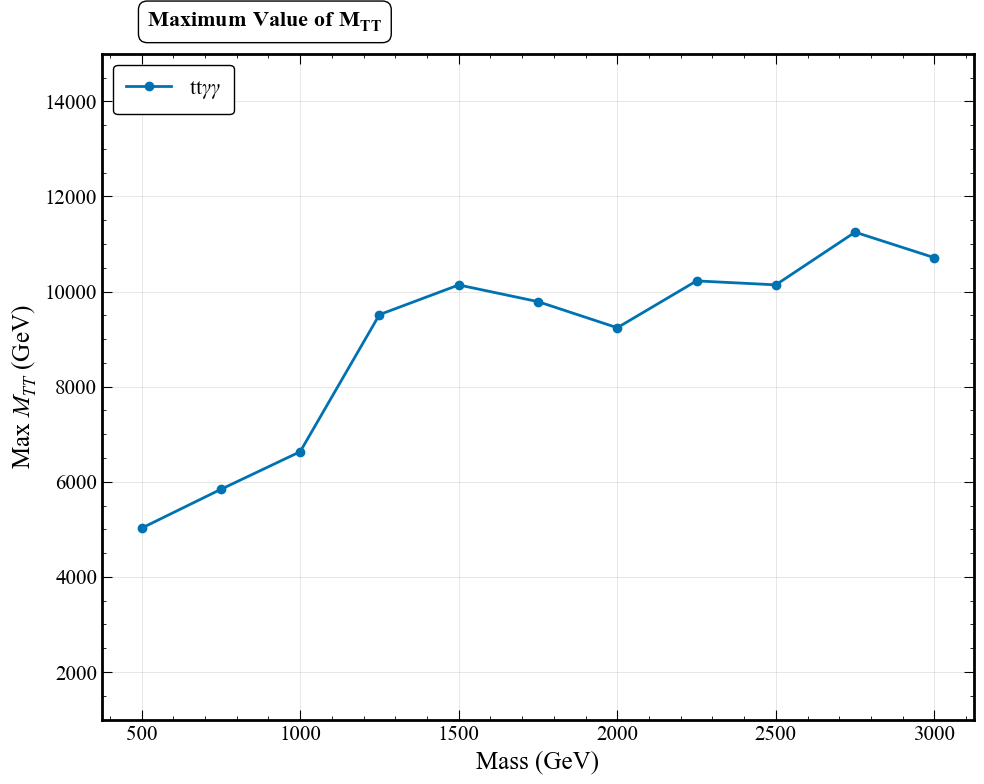

In [87]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
        'font.family': 'Times New Roman',      # controls all normal text
        'mathtext.fontset': 'custom',          # 'stix'/'stixsans' etc. ignore
        'mathtext.rm': 'Times New Roman',      # roman (upright) math text
        'mathtext.it': 'Times New Roman:italic',  # italic math text
        'mathtext.bf': 'Times New Roman:bold',    # bold math text
        'font.size': 12,
        'axes.labelsize': 16,
        'axes.titlesize': 16,
    })

# Unpack your lists
# x, y = zip(*MTT_max_tta)  # observed limit (median)
xaa, yaa = zip(*MTT_max_ttaa)

# Create the plot
plt.figure(figsize=(10, 8))


# Plot observed limit
# plt.plot(x, y, 'o-', color='#D55E00', linewidth=2, markersize=6, label='tt$\gamma$')
plt.plot(xaa, yaa, 'o-', color='#0072B2', linewidth=2, markersize=6, label='tt$\gamma\gamma$')


# Labels and formatting
plt.xlabel('Mass (GeV)', fontsize=18)
plt.ylabel(r'Max $M_{TT}$ (GeV)', fontsize=18)
# plt.title(r'Maximum Value of $M_{TT}$ or Allowed Lowest Value of $\Lambda_{eff}$', fontsize=20)

# Set y-scale to log if needed
# plt.yscale('log')

# Grid and ticks
ax = plt.gca()
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=3)
ax.tick_params(axis='both', which='major', length=7)
ax.tick_params(axis='both', which='both' , top=True, right=True, direction='in', labelsize=15)
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
# ax.set_xlim(left=1000, right=15000)
ax.set_ylim(bottom=1000, top=15000)

# Legend
plt.legend(loc='upper left', fontsize=16, frameon=True, fancybox=True,
           framealpha=1, edgecolor="black", borderpad=0.6)

ax.text(
    0.052, 1.03,
    #r'$\mathbf{95\%\ CL\ exclusion}$' +
    #r'$, 140\ \mathrm{fb}^{-1} \ $' +
    r'$\mathbf{Maximum\ Value\ of\ M_{TT}}$' ,
    # r' , $\mathbf{Untruncated \ Limits}$',
    transform=ax.transAxes,
    fontsize=16,
    ha='left',
    va='bottom',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='black',
        alpha=1
    )
)

# Save and show
plt.tight_layout()
plt.savefig('plots/MTT_MAX_ttaa_ATLAS.png', dpi=150, bbox_inches='tight')
plt.savefig('plots/MTT_MAX_ttaa_ATLAS.pdf', dpi=150, bbox_inches='tight')
plt.show()

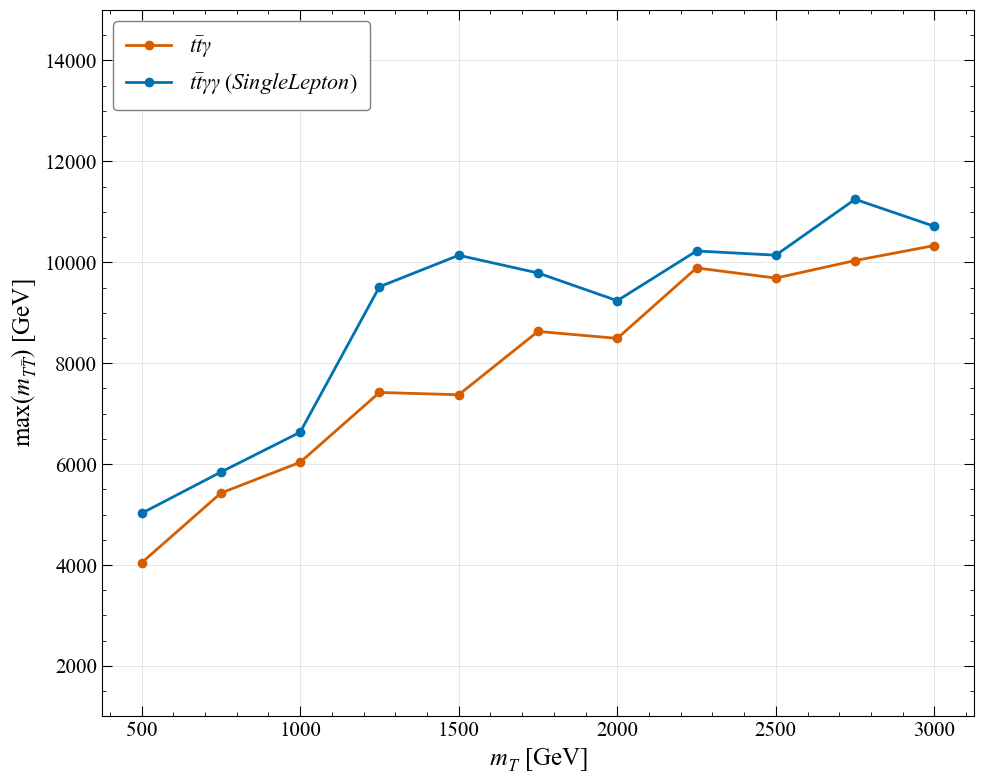

In [102]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
        'font.family': 'Times New Roman',      # controls all normal text
        'mathtext.fontset': 'custom',          # 'stix'/'stixsans' etc. ignore
        'mathtext.rm': 'Times New Roman',      # roman (upright) math text
        'mathtext.it': 'Times New Roman:italic',  # italic math text
        'mathtext.bf': 'Times New Roman:bold',    # bold math text
        'font.size': 12,
        'axes.labelsize': 16,
        'axes.titlesize': 16,
    })

# Unpack your lists
x, y = zip(*MTT_max_tta)  # observed limit (median)
xaa, yaa = zip(*MTT_max_ttaa)
xaa_tta, yaa_tta = zip(*sorted(MTT_max_ttaa_tta))

# Create the plot
plt.figure(figsize=(10, 8))


# Plot observed limit
plt.plot(x, y, 'o-', color='#D55E00', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma$')
plt.plot(xaa, yaa, 'o-', color='#0072B2', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (SingleLepton)$')
# plt.plot(xaa_tta, yaa_tta, 'o-', color='#009E73', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (DiLepton)$')


# Labels and formatting
plt.xlabel('$m_T$ [GeV]', fontsize=18)
plt.ylabel(r'max$(m_{T\bar{T}})$ [GeV]', fontsize=18)
# plt.title(r'Maximum Value of $M_{TT}$ or Allowed Lowest Value of $\Lambda_{eff}$', fontsize=20)

# Set y-scale to log if needed
# plt.yscale('log')

# Grid and ticks
ax = plt.gca()
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=3)
ax.tick_params(axis='both', which='major', length=7)
ax.tick_params(axis='both', which='both' , top=True, right=True, direction='in', labelsize=15)
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
ax.set_ylim(bottom=1000, top=15000)

# Legend
plt.legend(loc='upper left', fontsize=16, frameon=True, fancybox=True,
           framealpha=1, edgecolor="gray", borderpad=0.6)

# ax.text(
#     0.052, 1.03,
#     #r'$\mathbf{95\%\ CL\ exclusion}$' +
#     #r'$, 140\ \mathrm{fb}^{-1} \ $' +
#     r'$\mathbf{maximum\ Value\ of\ m_{TT}}$' ,
#     # r' , $\mathbf{Untruncated \ Limits}$',
#     transform=ax.transAxes,
#     fontsize=16,
#     ha='left',
#     va='bottom',
#     bbox=dict(
#         boxstyle='round,pad=0.4',
#         facecolor='white',
#         edgecolor='gray',
#         alpha=1
#     )
# )

# Save and show
plt.tight_layout()
plt.savefig('plots/MTT_MAX_tta_ttaa_ATLAS.png', dpi=150, bbox_inches='tight')
plt.savefig('plots/MTT_MAX_tta_ttaa_ATLAS.pdf', dpi=150, bbox_inches='tight')
plt.show()

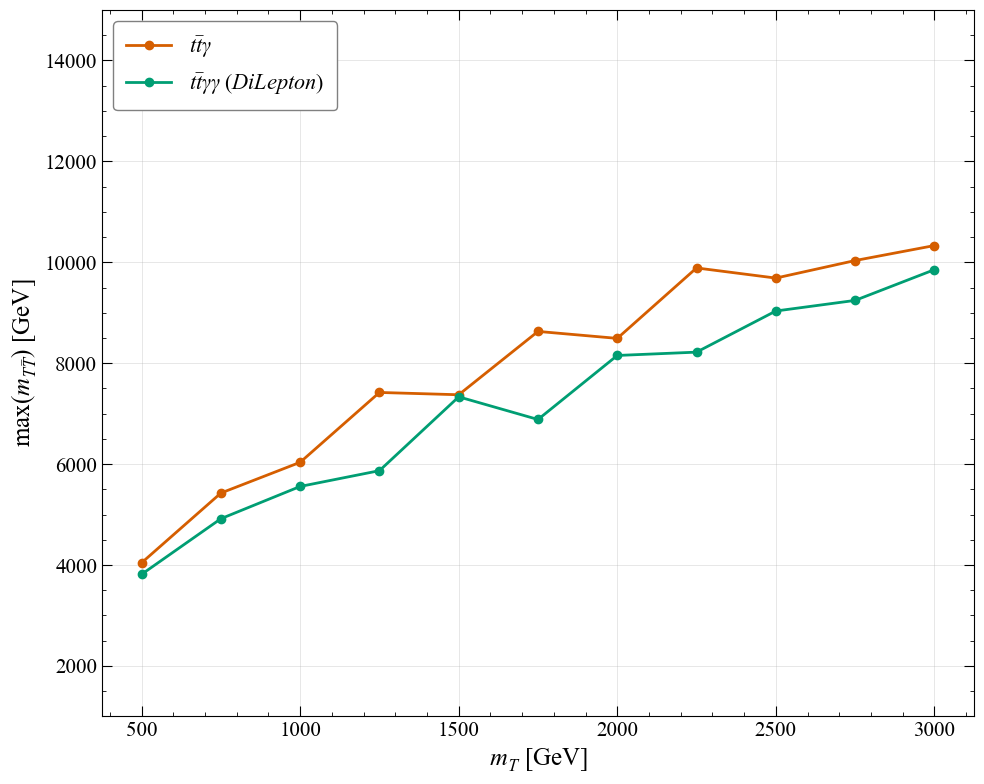

In [103]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
        'font.family': 'Times New Roman',      # controls all normal text
        'mathtext.fontset': 'custom',          # 'stix'/'stixsans' etc. ignore
        'mathtext.rm': 'Times New Roman',      # roman (upright) math text
        'mathtext.it': 'Times New Roman:italic',  # italic math text
        'mathtext.bf': 'Times New Roman:bold',    # bold math text
        'font.size': 12,
        'axes.labelsize': 16,
        'axes.titlesize': 16,
    })

# Unpack your lists
x, y = zip(*MTT_max_tta)  # observed limit (median)
xaa, yaa = zip(*MTT_max_ttaa)
xaa_tta, yaa_tta = zip(*sorted(MTT_max_ttaa_tta))

# Create the plot
plt.figure(figsize=(10, 8))


# Plot observed limit
plt.plot(x, y, 'o-', color='#D55E00', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma$')
# plt.plot(xaa, yaa, 'o-', color='#0072B2', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (SingleLepton)$')
plt.plot(xaa_tta, yaa_tta, 'o-', color='#009E73', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (DiLepton)$')


# Labels and formatting
plt.xlabel('$m_T$ [GeV]', fontsize=18)
plt.ylabel(r'max$(m_{T\bar{T}})$ [GeV]', fontsize=18)
# plt.title(r'Maximum Value of $M_{TT}$ or Allowed Lowest Value of $\Lambda_{eff}$', fontsize=20)

# Set y-scale to log if needed
# plt.yscale('log')

# Grid and ticks
ax = plt.gca()
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=3)
ax.tick_params(axis='both', which='major', length=7)
ax.tick_params(axis='both', which='both' , top=True, right=True, direction='in', labelsize=15)
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
ax.set_ylim(bottom=1000, top=15000)

# Legend
plt.legend(loc='upper left', fontsize=16, frameon=True, fancybox=True,
           framealpha=1, edgecolor="gray", borderpad=0.6)

# ax.text(
#     0.052, 1.03,
#     #r'$\mathbf{95\%\ CL\ exclusion}$' +
#     #r'$, 140\ \mathrm{fb}^{-1} \ $' +
#     r'$\mathbf{maximum\ Value\ of\ m_{TT}}$' ,
#     # r' , $\mathbf{Untruncated \ Limits}$',
#     transform=ax.transAxes,
#     fontsize=16,
#     ha='left',
#     va='bottom',
#     bbox=dict(
#         boxstyle='round,pad=0.4',
#         facecolor='white',
#         edgecolor='gray',
#         alpha=1
#     )
# )

# Save and show
plt.tight_layout()
plt.savefig('plots/MTT_MAX_tta_ttaa_CMS.png', dpi=150, bbox_inches='tight')
plt.savefig('plots/MTT_MAX_tta_ttaa_CMS.pdf', dpi=150, bbox_inches='tight')
plt.show()

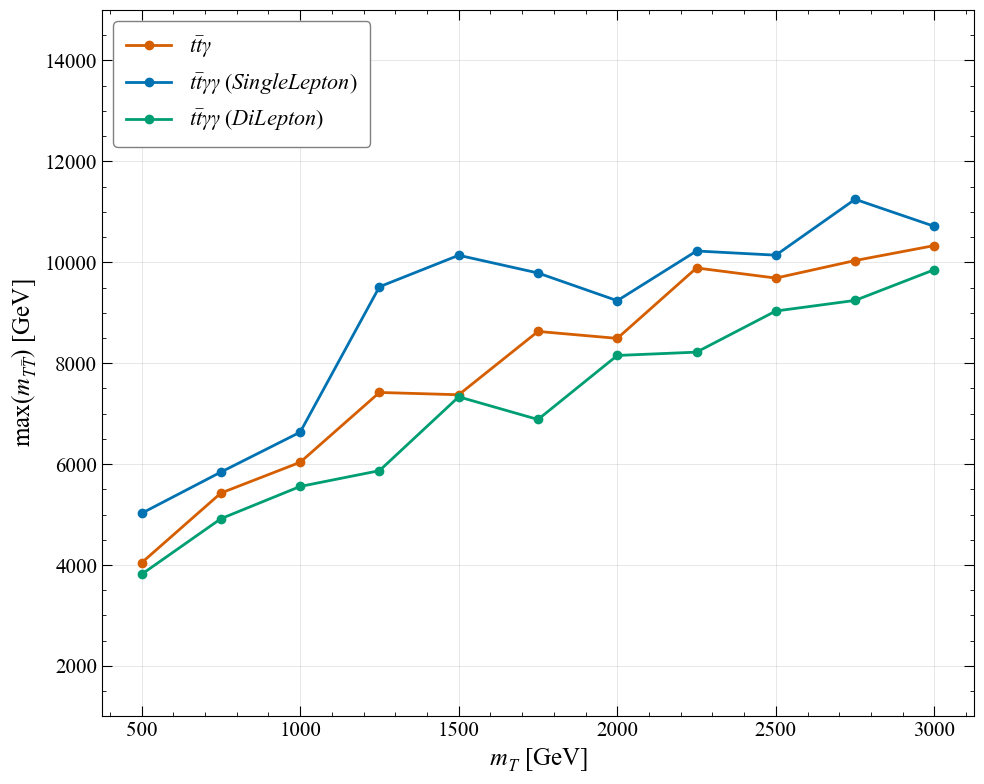

In [101]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
        'font.family': 'Times New Roman',      # controls all normal text
        'mathtext.fontset': 'custom',          # 'stix'/'stixsans' etc. ignore
        'mathtext.rm': 'Times New Roman',      # roman (upright) math text
        'mathtext.it': 'Times New Roman:italic',  # italic math text
        'mathtext.bf': 'Times New Roman:bold',    # bold math text
        'font.size': 12,
        'axes.labelsize': 16,
        'axes.titlesize': 16,
    })

# Unpack your lists
x, y = zip(*MTT_max_tta)  # observed limit (median)
xaa, yaa = zip(*MTT_max_ttaa)
xaa_tta, yaa_tta = zip(*sorted(MTT_max_ttaa_tta))

# Create the plot
plt.figure(figsize=(10, 8))


# Plot observed limit
plt.plot(x, y, 'o-', color='#D55E00', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma$')
plt.plot(xaa, yaa, 'o-', color='#0072B2', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (SingleLepton)$')
plt.plot(xaa_tta, yaa_tta, 'o-', color='#009E73', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (DiLepton)$')


# Labels and formatting
plt.xlabel('$m_T$ [GeV]', fontsize=18)
plt.ylabel(r'max$(m_{T\bar{T}})$ [GeV]', fontsize=18)
# plt.title(r'Maximum Value of $M_{TT}$ or Allowed Lowest Value of $\Lambda_{eff}$', fontsize=20)

# Set y-scale to log if needed
# plt.yscale('log')

# Grid and ticks
ax = plt.gca()
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=3)
ax.tick_params(axis='both', which='major', length=7)
ax.tick_params(axis='both', which='both' , top=True, right=True, direction='in', labelsize=15)
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
ax.set_ylim(bottom=1000, top=15000)

# Legend
plt.legend(loc='upper left', fontsize=16, frameon=True, fancybox=True,
           framealpha=1, edgecolor="gray", borderpad=0.6)

# ax.text(
#     0.052, 1.03,
#     #r'$\mathbf{95\%\ CL\ exclusion}$' +
#     #r'$, 140\ \mathrm{fb}^{-1} \ $' +
#     r'$\mathbf{maximum\ Value\ of\ m_{TT}}$' ,
#     # r' , $\mathbf{Untruncated \ Limits}$',
#     transform=ax.transAxes,
#     fontsize=16,
#     ha='left',
#     va='bottom',
#     bbox=dict(
#         boxstyle='round,pad=0.4',
#         facecolor='white',
#         edgecolor='gray',
#         alpha=1
#     )
# )

# Save and show
plt.tight_layout()
plt.savefig('plots/MTT_MAX_all_samples.png', dpi=150, bbox_inches='tight')
plt.savefig('plots/MTT_MAX_all_samples.pdf', dpi=150, bbox_inches='tight')
plt.show()

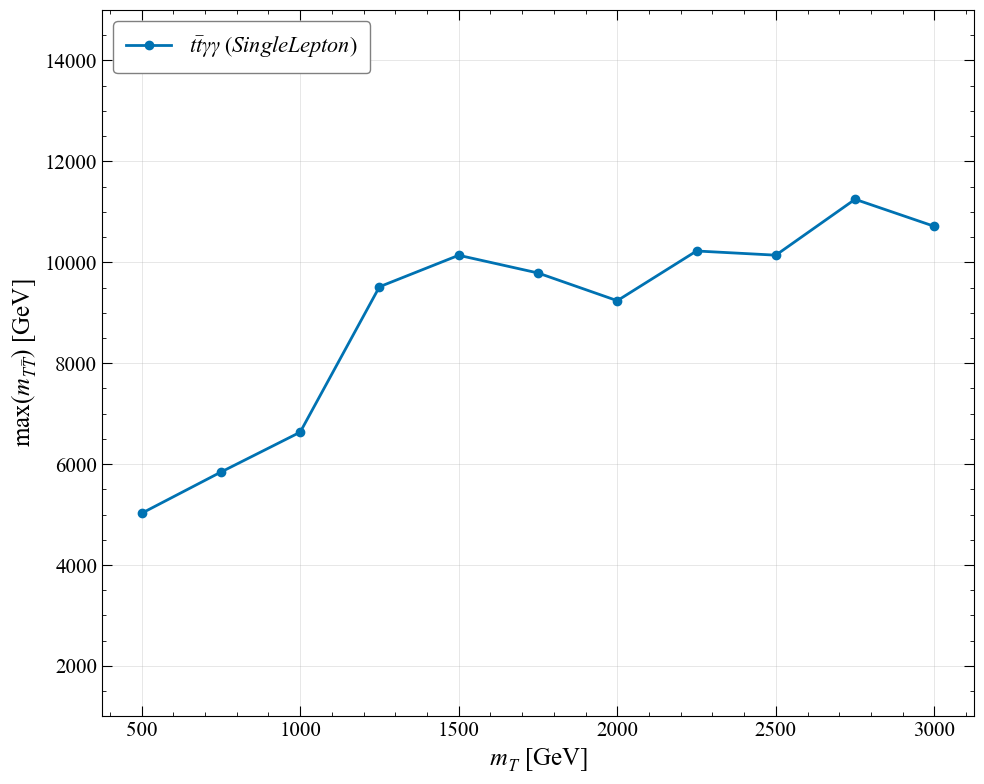

In [104]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
        'font.family': 'Times New Roman',      # controls all normal text
        'mathtext.fontset': 'custom',          # 'stix'/'stixsans' etc. ignore
        'mathtext.rm': 'Times New Roman',      # roman (upright) math text
        'mathtext.it': 'Times New Roman:italic',  # italic math text
        'mathtext.bf': 'Times New Roman:bold',    # bold math text
        'font.size': 12,
        'axes.labelsize': 16,
        'axes.titlesize': 16,
    })

# Unpack your lists
x, y = zip(*MTT_max_tta)  # observed limit (median)
xaa, yaa = zip(*MTT_max_ttaa)
xaa_tta, yaa_tta = zip(*sorted(MTT_max_ttaa_tta))

# Create the plot
plt.figure(figsize=(10, 8))


# Plot observed limit
# plt.plot(x, y, 'o-', color='#D55E00', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma$')
plt.plot(xaa, yaa, 'o-', color='#0072B2', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (SingleLepton)$')
# plt.plot(xaa_tta, yaa_tta, 'o-', color='#009E73', linewidth=2, markersize=6, label=r'$t\bar{{t}}\gamma\gamma\ (DiLepton)$')


# Labels and formatting
plt.xlabel('$m_T$ [GeV]', fontsize=18)
plt.ylabel(r'max$(m_{T\bar{T}})$ [GeV]', fontsize=18)
# plt.title(r'Maximum Value of $M_{TT}$ or Allowed Lowest Value of $\Lambda_{eff}$', fontsize=20)

# Set y-scale to log if needed
# plt.yscale('log')

# Grid and ticks
ax = plt.gca()
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=3)
ax.tick_params(axis='both', which='major', length=7)
ax.tick_params(axis='both', which='both' , top=True, right=True, direction='in', labelsize=15)
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
ax.set_ylim(bottom=1000, top=15000)

# Legend
plt.legend(loc='upper left', fontsize=16, frameon=True, fancybox=True,
           framealpha=1, edgecolor="gray", borderpad=0.6)

# ax.text(
#     0.052, 1.03,
#     #r'$\mathbf{95\%\ CL\ exclusion}$' +
#     #r'$, 140\ \mathrm{fb}^{-1} \ $' +
#     r'$\mathbf{maximum\ Value\ of\ m_{TT}}$' ,
#     # r' , $\mathbf{Untruncated \ Limits}$',
#     transform=ax.transAxes,
#     fontsize=16,
#     ha='left',
#     va='bottom',
#     bbox=dict(
#         boxstyle='round,pad=0.4',
#         facecolor='white',
#         edgecolor='gray',
#         alpha=1
#     )
# )

# Save and show
plt.tight_layout()
plt.savefig('plots/MTT_MAX_ttaa_ATLAS.png', dpi=150, bbox_inches='tight')
plt.savefig('plots/MTT_MAX_ttaa_ATLAS.pdf', dpi=150, bbox_inches='tight')
plt.show()